# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Sadiqah Quadery

**ID**: sq227

> **Due Date** 
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4750/bee4750-hw1-squadery`
   Installed HypergeometricFunctions ─ v0.3.28
   Installed EarCut_jll ────────────── v2.2.4+0
   Installed NetworkLayout ─────────── v0.4.10
   Installed OffsetArrays ──────────── v1.17.0
   Installed PDMats ────────────────── v0.11.35
   Installed StatsFuns ─────────────── v1.5.0
   Installed Unitful ───────────────── v1.23.1
   Installed StaticArrays ──────────── v1.9.14
   Installed StaticArraysCore ──────── v1.4.3
   Installed ArnoldiMethod ─────────── v0.4.0
   Installed Rmath_jll ─────────────── v0.5.1+0
   Installed Ratios ────────────────── v0.4.5
   Installed SpecialFunctions ──────── v2.5.1
   Installed GraphRecipes ──────────── v0.5.14
   Installed GeometryTypes ─────────── v0.8.5
   Installed Graphs ────────────────── v1.13.0
   Installed Inflate ───────────────── v0.1.5
   Installed ColorTypes ────────────── v0.11.5
   Installed Extents ───────────────── v0.1.6
   Installed AbstractTrees ─────────── v0.4.5
   Instal

Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [2]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [3]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [5]:
function minimum(array)
    if isempty(array)
        error("Array must not be empty")
    end
    min_value = array[1]
    # update minimum values
    for i in 2:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


The logical flaw is that min_value is initialized to 0. Since all entries in the example array are positive, none is < 0, so the loop never updates min_value and the function returns 0

To fix it we have to seed min_value with the first element of the array, then compare every remaining element to it.


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [7]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  return average_grade
end
average_grade = mean(student_grades)
@show average_grade;

average_grade = 94.4


The error means i tried to use the variable 'average_grade' in the global scope. but it doesn't exist there. average_grade is created inside class_average, so it only exists in that local scope.

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [11]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
     rand(1:6, 3) 
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = falses(n_trials) # boolean vector
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) >= 11) #at least 11
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.502


MethodError means I called a function with arugment types for which no method exists. Outcomes = zero(n_trials) returns the number 0 which is an integer (Int64) not a vector and outcomes[i] = ... tries to index into that integer.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [13]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [-0.402858193077954, 0.17163216613218168, -0.18169592947668356, 0.060514380686886415, -0.2591266252711959, -0.01737820236308285, 0.37319528099391985, 0.23362003830781186, -0.3090151132440434, -0.06824664473090836, 0.3127573063344131, -0.39730315107992675, 0.07450943943251365, 0.17821237477494634, -0.031914855823978905, 0.2901957389388936, -0.29439767231500735, -0.39428682614985444, 0.28469675398714955, -0.15391309414849141, 0.18410969908054953, 0.10996576619091203, 0.4366100026219155, 0.12668848258922027, -0.19376596222612996, 0.39947992422693535, -0.29291782437448555, 0.0258765406000393, -0.26110728751899714, -0.49303367510298224, -0.4484985564436411, 0.18580992405552932, -0.4685566065487725, 0.2636862043549746, -0.3541814667461207, 0.46525899668409465, 0.4703884817275342, 0.14350852326153452, -0.39614791770310454, -0.2798992807671117, -0.500126160487519, 0.13375959280637362, 0.37193108311289624, 0.25355217944131936, -0.2843864496790248, 0.012224016156722084

1000-element Vector{Float64}:
 -0.402858193077954
  0.17163216613218168
 -0.18169592947668356
  0.060514380686886415
 -0.2591266252711959
 -0.01737820236308285
  0.37319528099391985
  0.23362003830781186
 -0.3090151132440434
 -0.06824664473090836
  ⋮
 -0.12715199682996414
  0.3553833867930265
  0.2658817795877152
  0.3071997855512709
  0.35638130936574974
  0.15303872493357518
 -0.10958007508724765
 -0.11638803141199039
  0.4389100002859272

It tried to subtract a scalar from a vector by using -, because it says return vect - m, but m is a scalar we must use vect .-m

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

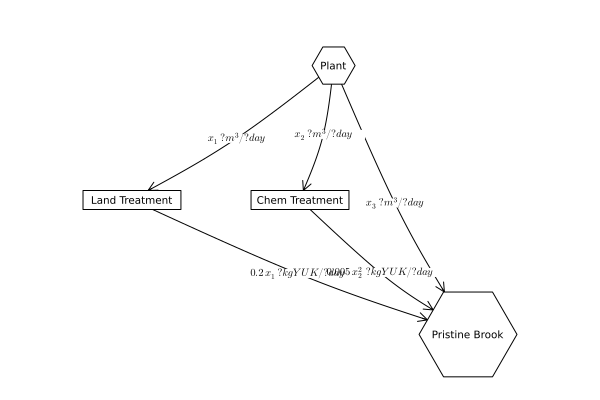

In [15]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"x_1\ \text{ m}^3/\text{day}",              # wastewater sent to land
    (1, 3) => L"x_2\ \text{ m}^3/\text{day}",              # wastewater to chemical treatment
    (1, 4) => L"x_3\ \text{ m}^3/\text{day}",              # direct discharge
    (2, 4) => L"0.2\,x_1\ \text{ kg YUK}/\text{day}",      # 20% of YUK from land reaches stream
    (3, 4) => L"0.005\,x_2^{2}\ \text{ kg YUK}/\text{day}" # remaining YUK after chem (1-e)*X2 = 0.005 X2^2
)
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

In [ ]:
Problem 2.1 Answer:

Variables:
x_1= wastewater sent to land disposal (m^3/day)
x_2= wastewater sent to chemical treatment (m^3/day)
x_3= wastewater directly discharged to the brook (m^3/day)

Parameters:
Total wastewater produced Q= 100 m^3/day
Influent YUK Concentration c_0=1 kg/m^3
Land disposal removes 80% of YUK / 20% reaches brook
Chem. treatment efficieny e(x_2)=1-0.005x_2
Effluent standard: at most 20kg/day

Model:
Land disposal cost: C_l(x_1)=((x_1)^2)/20 $/day
Chem treamtment cost: C_c(x_2)= 1.50 (x_2) $/day

C(x_1,x_2,x_3)= ((x_1)^2)/20 + 1.5(x_2)

Constraints:
Mass balance x_1 +x_2 + x_3 = Q= 100
YUL discharged to Brook : 0.2(x_1) + 0.005(x_2) + x_3 <= 20
variables bounds x_1,x_2, x_3 >= 0.        x_i <= 100

--> each term in the effluent constraint is in kg/day b/c c_0= 1 * flow
YUK=(1-e)c_0(x_2)=(0.005(x_2))*1*x_2= 0.005(x_2)^2





#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [14]:
# Inputs:
#   x1 = m^3/day sent to land disposal
#   x2 = m^3/day sent to chemical treatment
# Mass balance sets x3 = 100 - x1 - x2 (direct discharge).
# Model:
#   YUK = 0.2*x1 + 0.005*x2^2 + x3          (kg/day, since c0 = 1 kg/m^3)
#   cost = (x1^2)/20 + 1.5*x2               ($/day)

const Q = 100.0  # total wastewater (m^3/day)

function yuk_and_cost(x1::Real, x2::Real; Q::Real=Q)
    x3 = Q - x1 - x2
    if x1 < 0 || x2 < 0 || x3 < 0
        throw(ArgumentError("flows must be ≥ 0 and sum to ≤ $Q; got x1=$x1, x2=$x2, x3=$x3"))
    end
    yuk  = 0.2*x1 + 0.005*x2^2 + x3
    cost = (x1^2)/20 + 1.5*x2
    return (yuk, cost)  # <-- tuple
end

yuk_and_cost (generic function with 1 method)

To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [1]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]

Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

## References

List any external references consulted, including classmates.

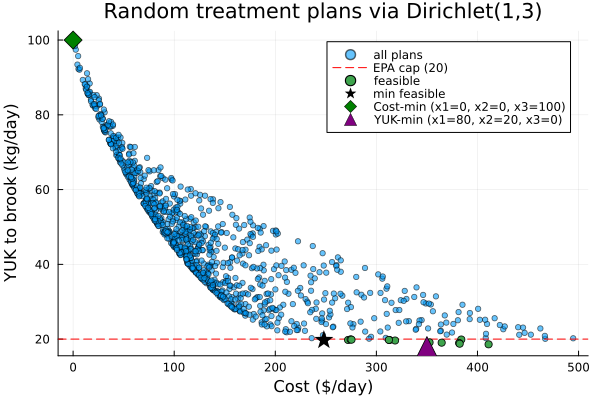


Total plans sampled: 1000
Plans meeting cap (YUK ≤ 20.0): 13
Cheapest feasible plan:
  cost = 248.058 $/day,  YUK = 19.748 kg/day
  flows: x1=61.804, x2=38.047, x3=0.149  (m^3/day)


In [ ]:


# Problem 2.3 

const Q = 100.0       # total wastewater (m^3/day)
const CAP = 20.0      # YUK cap (kg/day)

"""
    yuk_and_cost(x1, x2; Q=100)

Returns (yuk, cost) for the plan with
  x1 m^3/day to land, x2 m^3/day to chemical, and x3 = Q - x1 - x2 direct.
Model:  YUK = 0.2*x1 + 0.005*x2^2 + x3
        cost = x1^2/20 + 1.5*x2
"""
function yuk_and_cost(x1::Real, x2::Real; Q::Real=Q)
    x3 = Q - x1 - x2
    if x1 < 0 || x2 < 0 || x3 < 0
        throw(ArgumentError("flows must be ≥ 0 and sum to ≤ $Q; got x1=$x1, x2=$x2, x3=$x3"))
    end
    yuk  = 0.2*x1 + 0.005*x2^2 + x3
    cost = (x1^2)/20 + 1.5*x2
    return (yuk, cost)
end

# Sample 1,000 random feasible plans on the simplex
Random.seed!(42)
d = Dirichlet(ones(3))
P = rand(d, 1000)'              # 1000 × 3; rows sum to 1
X = Q .* P

x1 = X[:, 1];  x2 = X[:, 2];  x3 = X[:, 3]

# Evaluate model
outs = yuk_and_cost.(x1, x2)
yuk  = [o[1] for o in outs]
cost = [o[2] for o in outs]

# Feasibility & best feasible
feasible_mask = yuk .<= CAP + 1e-9
feasible_idx  = findall(feasible_mask)

best_idx = nothing
best_cost = Inf
if !isempty(feasible_idx)
    j = feasible_idx[argmin(cost[feasible_idx])]
    best_idx  = j
    best_cost = cost[j]
end

# Plot
scatter(cost, yuk;
        xlabel="Cost (\$/day)",
        ylabel="YUK to brook (kg/day)",
        title="Random treatment plans via Dirichlet(1,3)",
        label="all plans", alpha=0.6, ms=3, legend=:bottomright)

hline!([CAP]; color=:red, linestyle=:dash, label="EPA cap (20)")

if !isempty(feasible_idx)
    scatter!(cost[feasible_idx], yuk[feasible_idx]; label="feasible", ms=4)
    scatter!([cost[best_idx]], [yuk[best_idx]];
             marker=:star5, ms=10, color=:black, label="min feasible")
end

# Cost-minimizing plan (unconstrained): x1=0, x2=0, x3=100
y_cost, c_cost = yuk_and_cost(0.0, 0.0)
scatter!([c_cost], [y_cost]; marker=:diamond, ms=9, color=:green,
         label="Cost-min (x1=0, x2=0, x3=100)")

# YUK-minimizing plan: x1=80, x2=20, x3=0
y_ymin, c_ymin = yuk_and_cost(80.0, 20.0)
scatter!([c_ymin], [y_ymin]; marker=:utriangle, ms=10, color=:purple,
         label="YUK-min (x1=80, x2=20, x3=0)")
plot!(legend = :topright)  
display(current())

println("\nTotal plans sampled: ", length(cost))
println("Plans meeting cap (YUK ≤ $CAP): ", sum(feasible_mask))  # <-- count trues

if best_idx === nothing
    println("No feasible plans found in this sample.")
else
    println("Cheapest feasible plan:")
    println("  cost = $(round(best_cost, digits=3)) \$/day,  YUK = $(round(yuk[best_idx], digits=3)) kg/day")
    println("  flows: x1=$(round(x1[best_idx], digits=3)), x2=$(round(x2[best_idx], digits=3)), x3=$(round(x3[best_idx], digits=3))  (m^3/day)")
end


# Problem 2.4 (i attached it to the code in 2.3)

# Cost-minimizing plan (unconstrained): x1=0, x2=0, x3=100
y_cost, c_cost = yuk_and_cost(0.0, 0.0)
scatter!([c_cost], [y_cost]; marker=:diamond, ms=9, color=:green,
         label="Cost-min (x1=0, x2=0, x3=100)")

# YUK-minimizing plan: x1=80, x2=20, x3=0
y_ymin, c_ymin = yuk_and_cost(80.0, 20.0)
scatter!([c_ymin], [y_ymin]; marker=:utriangle, ms=10, color=:purple,
         label="YUK-min (x1=80, x2=20, x3=0)")

display(current())

- Julia Resources Page
